<a href="https://colab.research.google.com/github/stu97805-sys/F3933/blob/main/%E3%80%8Cstk_ch09_ipynb%E3%80%8D%E7%9A%84%E5%89%AF%E6%9C%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CH-09 讓 AI 評估投資組合風險

## 9-1 資金管理

### 1️⃣ 單次賭局的期望資產

In [ ]:
bet = 500 # 下注金額
win_rate = 0.8 # 勝率
wealth = 1000 # 資產

# 期望獲利
gain = 0.8 *  bet + (0.2 * -bet)
wealth += gain
print("這次賭局期望獲利為:",gain)
print("期望總資產為:",wealth)

這次賭局期望獲利為: 300.0
期望總資產為: 1300.0


### 2️⃣ 單一賭局的隨機結果

In [ ]:
import random

def single_bet(bet, win_rate, wealth, odds=1, verbose=True):
  # 單一賭局獲利
  if random.uniform(0,1) <= win_rate:
    gain = bet * odds
  else:
    gain = -bet
  wealth += gain

  if verbose:
    print("這次賭局的獲利為:", gain)
    print("總資產為:", wealth)

  return wealth

single_bet(bet=1000, win_rate=0.8, wealth=1000)

這次賭局的獲利為: -1000
總資產為: 0


0

### 3️⃣ 重複賭局的資產變化

In [ ]:
def simulate_bets(initial_wealth, bet_ratio,
                  win_rate, num_bets=100, odds=1, verbose=True):
  wealths = [initial_wealth]
  wealth = initial_wealth
  for i in range(num_bets):
    bet = wealth * bet_ratio
    wealth = single_bet(bet=bet, win_rate=win_rate,
                        wealth=wealth, odds=odds, verbose=verbose)
    wealths.append(wealth)
    # 輸光就跳出迴圈
    if wealth <= 0:
        break
  return wealths

simulate_bets(initial_wealth=1000, bet_ratio=1 ,win_rate=0.8)

這次賭局的獲利為: 1000
總資產為: 2000
這次賭局的獲利為: 2000
總資產為: 4000
這次賭局的獲利為: 4000
總資產為: 8000
這次賭局的獲利為: 8000
總資產為: 16000
這次賭局的獲利為: -16000
總資產為: 0


[1000, 2000, 4000, 8000, 16000, 0]

### 4️⃣ 不同下注量的資產成長幅度

最好的下注比例為: Ratio 0.5, 最終資產：9444649164688.18


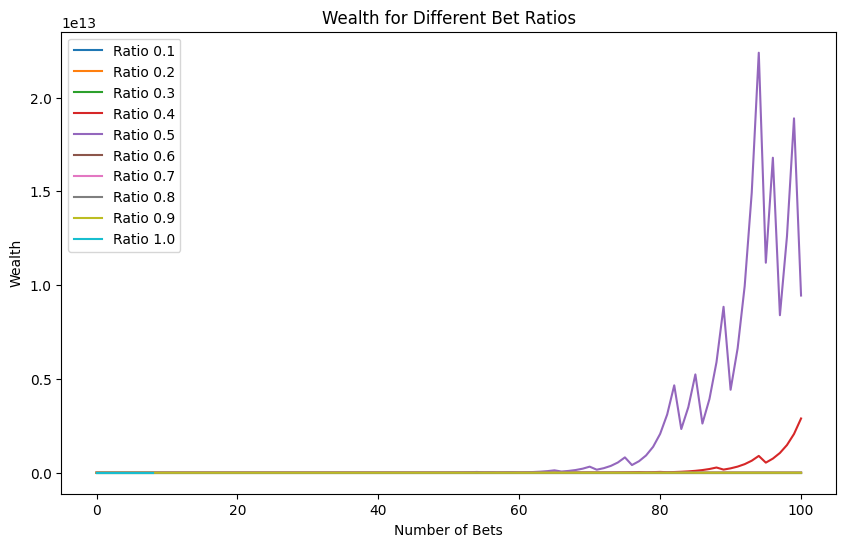

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 設定變數
initial_wealth = 1000
bet_ratios = [i/10 for i in range(1, 11)]  # 從10%到全押的下注比例
num_bets = 100
win_rate =0.8

df = pd.DataFrame()
# 模擬各比例下注
for bet_ratio in bet_ratios:
  wealths = simulate_bets(initial_wealth, bet_ratio, win_rate, num_bets, verbose=False)
  df[f'Ratio {bet_ratio}'] = pd.Series(wealths)

final_wealths = df.iloc[-1]
max_ratio = final_wealths.idxmax() # 找到最好的下注比例
max_value = final_wealths.max()  # 最高資產

print(f"最好的下注比例為: {max_ratio}, 最終資產：{max_value}")

# 繪製圖表
ax = df.plot(figsize=(10,6), legend=True, title='Wealth for Different Bet Ratios')
ax.set_xlabel('Number of Bets')
ax.set_ylabel('Wealth')
plt.show()

### 5️⃣ 倍倍下注法

下注方法排名：
第1名:Ratio 0.7, 最終資產：98095587216882.67
第2名:Ratio 0.5, 最終資產：349801820914.3771
第3名:Ratio 0.6, 最終資產：234854258277.3833
第4名:Ratio 0.8, 最終資產：224328958700.7961
第5名:Ratio 0.4, 最終資產：17917105954.198242
第6名:Ratio 0.3, 最終資產：560510396.6562583
第7名:Ratio 0.9, 最終資產：72076763.67786849
第8名:Ratio 0.2, 最終資產：24905738.487154614
第9名:Ratio 0.1, 最終資產：454690.1316370175
第10名:double_bet, 最終資產：1075.0
第11名:Ratio 1.0, 最終資產：nan


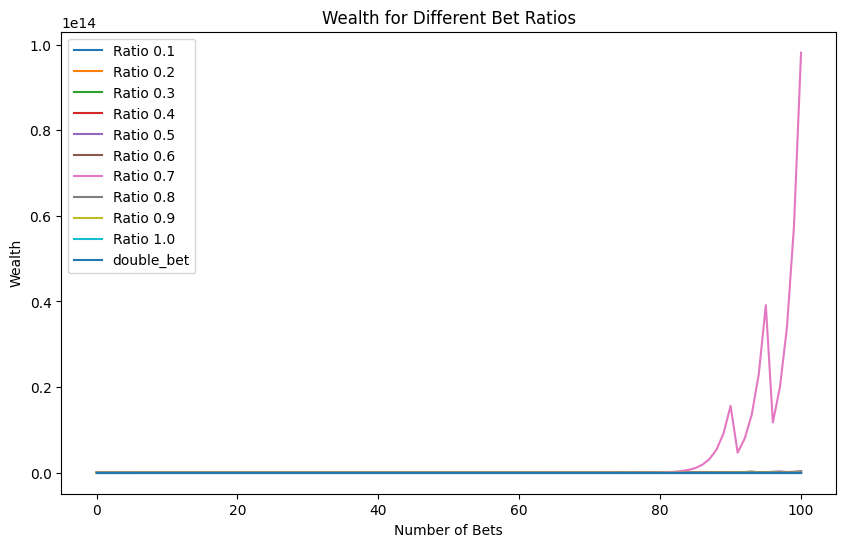

In [ ]:
def double_bet(initial_wealth, win_rate, num_bets=100, odds=1):
  wealths = [initial_wealth]
  wealth = initial_wealth
  initial_bet = 1
  bet = initial_bet
  for i in range(num_bets):
    if random.uniform(0, 1) <= win_rate:
      # 若贏了，則下注初始金額
      wealth += bet * odds
      bet = initial_bet
    else:
      # 若輸了，則加倍下注金額
      wealth -= bet
      bet *= 2
    wealths.append(wealth)

    # 輸光就跳出迴圈
    if wealth <= 0:
      break

  return wealths

# 設定變數
initial_wealth = 1000
bet_ratios = [i/10 for i in range(1, 11)]  # 從10%到全押的下注比例
num_bets = 100
win_rate =0.8

df = pd.DataFrame()
# 模擬各比例下注
for bet_ratio in bet_ratios:
  wealths = simulate_bets(initial_wealth, bet_ratio, win_rate, num_bets, verbose=False)
  df[f'Ratio {bet_ratio}'] = pd.Series(wealths)

# 倍倍下注法模擬結果
wealths_double = double_bet(initial_wealth, win_rate, num_bets)
df['double_bet'] = pd.Series(wealths_double)

# 下注法排名
final_wealths = df.iloc[-1]
sorted_wealths = final_wealths.sort_values(ascending=False)
print("下注方法排名：")
i = 1
for index, value in zip(sorted_wealths.index, sorted_wealths.values):
    print(f"第{i}名:{index}, 最終資產：{value}")
    i += 1

# 繪製圖表
ax = df.plot(figsize=(10,6), legend=True, title='Wealth for Different Bet Ratios')
ax.set_xlabel('Number of Bets')
ax.set_ylabel('Wealth')
plt.show()

### 6️⃣ 凱利公式 Kelly formula

In [ ]:
def kelly_formula(p,b):
  # 最佳下注比例
  best_bet = (b * p - (1 - p)) / b
  # 如果下注比例小於等於 0，則設為 0
  if best_bet <= 0:
      return 0
  # 取到小數點後兩位
  best_bet = round(best_bet,2)
  return best_bet

kelly_formula(p=0.8,b=1)

best_bet = kelly_formula(p=0.8, b=1)
print("最佳下注比例為:", best_bet)

最佳下注比例為: 0.6


### 7️⃣ 安裝及匯入套件

In [ ]:
!pip install openai
!pip install yfinance
!pip install backtesting
!pip install bokeh==2.4.3 # 繪圖套件
import openai # 串接 OpenAI API
import yfinance as yf
import numpy as np
import pandas as pd # 資料處理套件
from scipy.stats import norm
import datetime as dt # 時間套件
from backtesting import Backtest, Strategy
from backtesting.lib import crossover

ImportError: cannot import name 'Iterator' from 'typing_extensions' (/usr/local/lib/python3.10/dist-packages/typing_extensions.py)

### 8️⃣ 取得回測結果

In [ ]:
# 取得股價資料
stock_id = "1438.tw"
df = yf.download(stock_id, period="5y")
df['ma1'] = df['Close'].rolling(window=5).mean()
df['ma2'] = df['Close'].rolling(window=10).mean()


# 定義回測策略
class CrossStrategy(Strategy):
  def init(self):
    super().init()

  def next(self):
    if crossover(self.data.ma1, self.data.ma2):
      self.buy(size=1)
    elif crossover(self.data.ma2, self.data.ma1):
      self.sell(size=1)


# 回測結果
backtest = Backtest(df,
        CrossStrategy,
        cash=100000,
        commission=0.004,
        margin=1,
        hedging=False,
        trade_on_close=False,
        exclusive_orders=False,
        )
stats = backtest.run()
print(stats)

### 9️⃣ 計算賠率、取得勝率及最佳下注比例

In [ ]:
# 先計算出獲利及虧損時的平均報酬
def trades_returns(returns):
    profits = returns[returns > 0].tolist()
    losses = returns[returns < 0].tolist()

    # 確保分母不為零
    avg_profit = sum(profits) / len(profits) if profits else 0
    avg_loss = sum(losses) / len(losses) if losses else 0

    return avg_profit, avg_loss

avg_profit, avg_loss = trades_returns(stats['_trades']['ReturnPct'])
print(f"獲利時的平均報酬:{avg_profit*100:.2f}%")
print(f"虧損時的平均報酬:{avg_loss*100:.2f}%")
print("--------------------------")

# 用平均獲利除以平均虧損來推估賠率
b = -avg_profit/avg_loss
p = stats['Win Rate [%]']/100
print(f"賠率為:{b:.2f}")
print(f"勝率為:{p*100:.2f}%")
print("--------------------------")

# 代入凱利公式
best_bet = kelly_formula(p=p, b=b)
print("最佳下注比例為:", best_bet)

### 🔟 用凱利公式來更改策略

In [ ]:
# 定義回測策略
class CrossStrategy(Strategy):
  kelly_ratio = 0.3  # 凱利公式的下注比率

  def init(self):
    super().init()

  def next(self):

    size = (self.equity * self.kelly_ratio) / self.data.Close[-1]
    size = max(round(size), 1) # 確保交易股數為整數

    if crossover(self.data.ma1, self.data.ma2):
        self.buy(size=size)
    elif crossover(self.data.ma2, self.data.ma1):
        self.sell(size=size)


# 回測結果
backtest = Backtest(df,
        CrossStrategy,
        cash=100000,
        commission=0.004,
        margin=1,
        hedging=False,
        trade_on_close=False,
        exclusive_orders=False,
        )
stats = backtest.run()
print(stats)

## 9-2 投資組合資金分配與風險管理

### 1️⃣1️⃣ 掛載雲端硬碟 & 安裝套件

In [ ]:
!pip install gdown
import gdown
import os
!git clone https://github.com/gamer00801/Document_loader.git
%cd Document_loader
!pip install -r requirements.txt
from Stock_DB import StockDB
%cd ..
from google.colab import drive
drive.mount('/content/drive')

fatal: destination path 'Document_loader' already exists and is not an empty directory.
/content/Document_loader
/content
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1️⃣2️⃣ 下載資料庫

In [ ]:
# 指定下載路徑
!mkdir -p "/content/drive/MyDrive/StockGPT/"
output_path = '/content/drive/MyDrive/StockGPT/'
if not os.path.exists(output_path):
            os.makedirs(output_path)
# 檢查資料庫是否存在
stock_db_path = output_path + 'stock.db'
if not os.path.exists(stock_db_path):
    print("下載資料庫中...")
    url = 'https://drive.google.com/uc?export=download&id=1-3ikZdKvQCTKFnDeC43xjZfMNS4K-RCx'
    gdown.download(url, stock_db_path)
    print("下載完成")
else:
    print("無需下載")

無需下載


In [ ]:
stock_db = StockDB()
stock_db.renew()
stock_db.close()

線上讀取股號、股名、及產業別
要更新的公司：        股號       股名       產業別
680  4736       泰博     生技醫療業
729  5292       華懋      綠能環保
825  6472       保瑞     生技醫療業
853  6658       聯策     其他電子業
868  6742       澤米       光電業
883  6805      富世達    電子零組件業
892  6906      現觀科      數位雲端
893  6916       華凌       光電業
894  6933  AMAX-KY  電腦及週邊設備業
895  6937       天虹      半導體業
941  8476       台境      綠能環保


[                       0%%                      ]

日頻基本資料的最後更新日： 2024-01-19
開始日期： 2024-01-20


[*********************100%%**********************]  988 of 988 completed


更新日本益比、融資融卷、三大法人資料
完成更新: 20240122
             日期    股號         開盤價         最高價         最低價         收盤價  \
0    2024-01-22  1101   32.400002   32.650002   32.299999   32.299999   
1    2024-01-22  1102   39.450001   39.650002   39.450001   39.549999   
2    2024-01-22  1103   18.000000   18.200001   18.000000   18.100000   
3    2024-01-22  1104   28.450001   28.700001   28.250000   28.549999   
4    2024-01-22  1108   15.100000   15.250000   15.100000   15.150000   
..          ...   ...         ...         ...         ...         ...   
943  2024-01-22  9944   20.200001   20.200001   20.000000   20.150000   
944  2024-01-22  9945   35.549999   35.650002   35.299999   35.450001   
945  2024-01-22  9946   20.900000   21.450001   20.750000   21.049999   
946  2024-01-22  9955   23.200001   23.450001   23.100000   23.350000   
947  2024-01-22  9958  192.000000  207.000000  192.000000  205.500000   

            還原價        成交量   殖利率    日本益比 股價淨值比   三大法人買賣超股數 融資買入 融卷賣出  
0     32.299999  9

若需更新資料庫, 可執行以下程式碼

```
stock_db = StockDB()
stock_db.renew()
stock_db.close()
```



### 1️⃣3️⃣ 設定投資組合

In [ ]:
# 以10檔股票為例
stock_list = ['5244','1438','3025','3036','2443']

condition = f"股號 IN ({','.join(map(str, stock_list))})"

# 從資料庫取出資料
stock_db = StockDB()
df = stock_db.get(table="日頻", where=condition)
df = df.dropna()
df.head()

,股號,日期,開盤價,最高價,最低價,收盤價,還原價,成交量,殖利率,日本益比,股價淨值比,三大法人買賣超股數,融資買入,融卷賣出
0,1438,2015-01-05,12.62,13.0,12.62,12.98,12.98,33000.0,0.0,162.25,1.25,-11000,0.0,0.0
2,1438,2015-01-07,13.00,13.6,13.00,13.02,13.02,97000.0,0.0,162.75,1.25,-41000,0.0,0.0
3,1438,2015-01-08,13.02,13.3,12.74,13.30,13.30,47000.0,0.0,166.25,1.28,27000,0.0,0.0
5,1438,2015-01-12,13.16,13.4,12.82,13.20,13.20,9500.0,0.0,165.0,1.27,-1000,0.0,0.0
6,1438,2015-01-13,13.00,13.3,13.00,13.04,13.04,9000.0,0.0,163.0,1.26,2000,0.0,0.0


###1️⃣4️⃣ 計算每月的漲幅或跌幅

In [ ]:
# 設定日期為索引
df.set_index('日期', inplace=True)
df = df[df.index > '2017-01-01']

# 訓練資料與測試資料
start = "2021-01-01"
end = "2023-10-10"
train_df = df[df.index <= start]
test_df = df[(df.index > start) & (df.index <= end)]

# 取出每月最後一個交易日的收盤價
monthly_closing = train_df.groupby('股號')\
                          .resample('M')['收盤價'].last()

# 計算每月的漲幅或跌幅
monthly_return = monthly_closing.groupby(level=0)\
                                .pct_change().fillna(0)

print(monthly_return)

KeyError: "None of ['日期'] are in the columns"

###1️⃣5️⃣ 計算每檔股票的最佳下注比例

In [ ]:
results = []

# 計算每檔股票的最佳下注比例
for stock in stock_list:
    str_stock = str(stock)
    avg_profit, avg_loss = trades_returns(monthly_return[str_stock])
    b = -avg_profit/avg_loss # 賠率
    p = len(monthly_return[str_stock][monthly_return[str_stock] > 0]
            ) / len(monthly_return[str_stock])  # 勝率
    best_bet = kelly_formula(p=p, b=b) # 下注比例

    results.append([stock, avg_profit, avg_loss, p, b, best_bet])

# 合併為 DataFrame
df_results = pd.DataFrame(results,
              columns=['股號', '平均漲幅', '平均跌幅',
                  '勝率', '賠率', '下注比例'])

total_bet = df_results['下注比例'].sum()
df_results['資金分配'] = df_results['下注比例'] / total_bet

df_results

KeyError: '5244'

###1️⃣6️⃣ 比較平均分配與使用下注比例的報酬

In [ ]:
# 計算測試資料的每月漲幅或跌幅
monthly_closing_test = test_df.groupby('股號')\
                .resample('M')['收盤價'].last()
monthly_return_test = monthly_closing_test.groupby(level=0)\
                                .pct_change().fillna(0)
first_price = monthly_closing_test.groupby('股號').first()
last_price = monthly_closing_test.groupby('股號').last()


# 計算報酬率
returns = (last_price /first_price)
df_results['股號'] = df_results['股號'].astype(str)
df_results_test = df_results.merge(
    returns.rename('報酬率'), left_on='股號', right_index=True)
display(df_results_test)

# 設定初始資金
initial_capital = 100000

# 平均分配策略的結果
avg = initial_capital / len(stock_list)
avg_strategy = sum(df_results_test['報酬率'] * avg)

# 使用下注比例的策略結果
bet_strategy = sum(df_results_test['報酬率'] *(
    df_results_test['資金分配'] * initial_capital))

print(f"平均分配策略的最終資金: {avg_strategy}")
print(f"下注比例策略的最終資金: {bet_strategy}")

NameError: name 'df_results' is not defined

###1️⃣7️⃣ 與大盤績效進行比較

[*********************100%%**********************]  1 of 1 completed


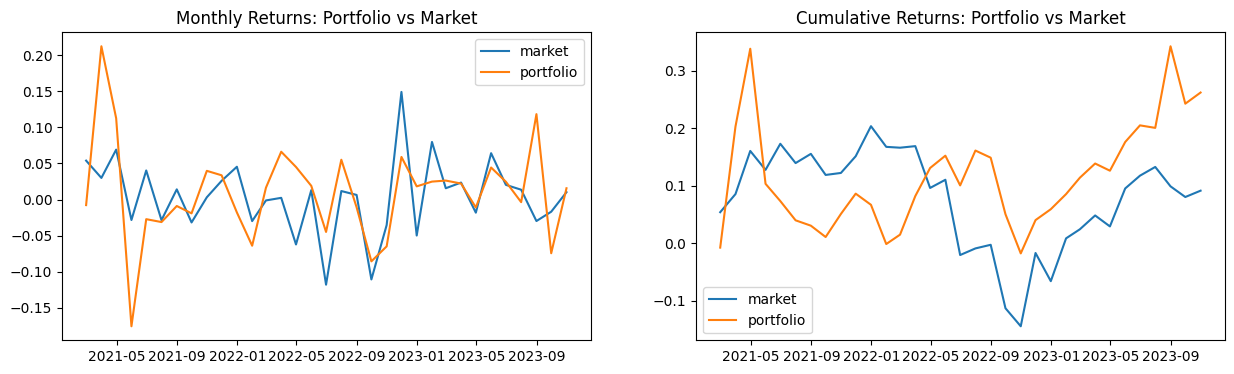

In [ ]:
# 投組每月報酬
returns_df = pd.concat([monthly_return_test[str(stock)]
                         for stock in stock_list], axis=1)
returns_df.columns = stock_list
weights = df_results['資金分配'].values
returns_df['投組報酬'] = returns_df[stock_list].dot(weights)

# 計算大盤報酬
market_index = yf.download("^TWII",start=start,end=end)
market_closing = market_index.resample('M')['Close'].last()
market_return = market_closing.pct_change().fillna(0)
returns_df['大盤報酬'] = market_return

# 累積報酬
returns_df['投組累積報酬'] = (1 + returns_df['投組報酬']).cumprod() - 1
returns_df['大盤累積報酬'] = (1 + returns_df['大盤報酬']).cumprod() - 1

# 繪製大盤與投組績效
returns_df = returns_df.drop(returns_df.index[0])
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(15, 4))

ax1.plot(returns_df['大盤報酬'], label="market")
ax1.plot(returns_df['投組報酬'], label="portfolio")
ax1.set_title("Monthly Returns: Portfolio vs Market")
ax1.legend()

ax2.plot(returns_df['大盤累積報酬'], label="market")
ax2.plot(returns_df['投組累積報酬'], label="portfolio")
ax2.set_title("Cumulative Returns: Portfolio vs Market")
ax2.legend()

plt.show()

###1️⃣8️⃣ 投資組合標準差 (σ)

In [ ]:
# 計算共變異數矩陣
stk_returns_df = returns_df.iloc[:, :-4]
cov_matrix = stk_returns_df.cov()
display(cov_matrix)

# 計算投資組合的報酬與標準差
portfolio_return = np.dot(weights, stk_returns_df.mean().values)
portfolio_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix.values, weights)))

# 轉換成年化
annualized_portfolio_return = (1 + portfolio_return)**12 - 1
annualized_portfolio_std = portfolio_std * (12**0.5)
annualized_market_return = (1 + market_return.mean())**12 - 1
annualized_market_std = market_return.std() * (12**0.5)

print(f"投資組合的年化報酬率:{annualized_portfolio_return*100:.2f}%")
print(f"投資組合的年化標準差:{annualized_portfolio_std*100:.2f}%")

print(f"大盤指數的年化報酬率:{annualized_market_return*100:.2f}%")
print(f"大盤指數的年化標準差:{annualized_market_std*100:.2f}%")

,1438,3622
1438,0.005133,0.002696
3622,0.002696,0.007511


投資組合的年化報酬率:11.72%
投資組合的年化標準差:23.47%
大盤指數的年化報酬率:4.70%
大盤指數的年化標準差:17.68%


###1️⃣9️⃣ 風險值 (Value at Risk, VaR)

In [ ]:
confidence_level = 0.95

# 月頻 VaR
VaR = portfolio_return - portfolio_std * norm.ppf(confidence_level)
# 年頻 VaR
VaR_annualized = VaR * (12**0.5)

print(f"在 {confidence_level*100:.0f}% 的信心水準下,\
 下個月的最大可能損失為：{VaR*100:.2f}%")
print(f"在 {confidence_level*100:.0f}% 的信心水準下,\
 明年最大可能損失為：{VaR_annualized*100:.2f}%")

在 95% 的信心水準下, 下個月的最大可能損失為：-10.21%
在 95% 的信心水準下, 明年最大可能損失為：-35.38%


###2️⃣0️⃣ beta 係數 (β)


In [ ]:
# 計算β係數
portfolio_market_cov = returns_df[['投組報酬', '大盤報酬']].cov()\
                               .iloc[0, 1]
market_var = returns_df['大盤報酬'].var()
portfolio_beta = portfolio_market_cov / market_var

print(f"投組與大盤的共變異數為：{portfolio_market_cov:.5f},\
    大盤變異數為：{market_var:.5f}")
print(f"投資組合的β係數：{portfolio_beta:.2f}")

投組與大盤的共變異數為：0.00148,    大盤變異數為：0.00269
投資組合的β係數：0.55


###2️⃣1️⃣ 夏普比率 (Sharpe Ratio)

In [ ]:
# 設定無風險利率
risk_free_rate = 0.015/12  # 轉換成月頻 (算術平均)

average_return = returns_df['投組報酬'].mean()
portfolio_std = returns_df['投組報酬'].std()

sharpe_ratio = (average_return - risk_free_rate) / portfolio_std
sharpe_ratio_annualized = sharpe_ratio * (12**0.5)

print(f"投資組合的夏普比率：{sharpe_ratio:.2f}")
print(f"年化的夏普比率：{sharpe_ratio_annualized:.2f}")

投資組合的夏普比率：0.12
年化的夏普比率：0.41
